In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
ss = [
    "International traffic/capita",
    "International traffic trend",
    "International segment trend",
    "Domestic traffic/capita",
    "Domestic traffic trend",
    "Domestic segment trend",
]


x_sort = [
    'Population size', 
    'Trend of population size', 
    'Population density',
    'Trend of population density', 
    'Proportion of individuals aged 60–80y',
    'Trend of GPD per capita',
    'Trend of nighttime light', 
    'Trend of unemployment rate',
    'Electricity coverage',
    'Tolls in armed conflicts/warfare', 
    'Number of refugees per 100,000 individuals',
    'Visa-free score',
    'Visa-free ranking', 
    'Inflow FDI',
    'International merchandise trade (% of GDP)',
    'Tend of trade in import merchandise', 
    'Trend of trade in export commercial services',
    'Area of countries/regions',
    'Number of seats per 100,000 individuals'
]

In [3]:
!pwd

/root/zengjf/project/airTraffic/airEmission


In [4]:
reg_ = pd.read_excel("../airTrend/results/regression_res.xlsx", index_col=0, sheet_name='main')
reg_ = reg_.loc[x_sort, ss]
reg_

,International traffic/capita,International traffic trend,International segment trend,Domestic traffic/capita,Domestic traffic trend,Domestic segment trend
Population size,NaN,NaN,NaN,NaN,"263.48 (92.91, 434.04)",NaN
Trend of population size,NaN,NaN,NaN,"207.23 (4.58, 409.89)",NaN,NaN
Population density,NaN,NaN,NaN,"-168.56 (-420.89, 83.77)",NaN,NaN
Trend of population density,NaN,NaN,NaN,NaN,NaN,"-527.03 (-993.45, -60.61)"
Proportion of individuals aged 60–80y,NaN,"766.04 (483.3, 1048.79)",NaN,NaN,"-493 (-730.87, -255.12)",NaN
Trend of GPD per capita,NaN,NaN,NaN,NaN,"316.73 (129.4, 504.05)",NaN
Trend of nighttime light,NaN,NaN,NaN,NaN,NaN,"579.89 (173.01, 986.78)"
Trend of unemployment rate,NaN,NaN,NaN,"-108.77 (-248.85, 31.3)",NaN,NaN
Electricity coverage,NaN,NaN,NaN,NaN,"162.32 (-43.29, 367.93)",NaN
Tolls in armed conflicts/warfare,NaN,"217.03 (63.84, 370.22)","10.21 (-177.44, 197.86)",NaN,NaN,"-172.39 (-717.92, 373.14)"


In [5]:
reg_.index

Index(['Population size', 'Trend of population size', 'Population density',
       'Trend of population density', 'Proportion of individuals aged 60–80y',
       'Trend of GPD per capita', 'Trend of nighttime light',
       'Trend of unemployment rate', 'Electricity coverage',
       'Tolls in armed conflicts/warfare',
       'Number of refugees per 100,000 individuals', 'Visa-free score',
       'Visa-free ranking', 'Inflow FDI',
       'International merchandise trade (% of GDP)',
       'Tend of trade in import merchandise',
       'Trend of trade in export commercial services',
       'Area of countries/regions', 'Number of seats per 100,000 individuals'],
      dtype='str')

In [6]:
def parse_res(x):
    if not pd.isna(x):
        return float(x.split(" ")[0])

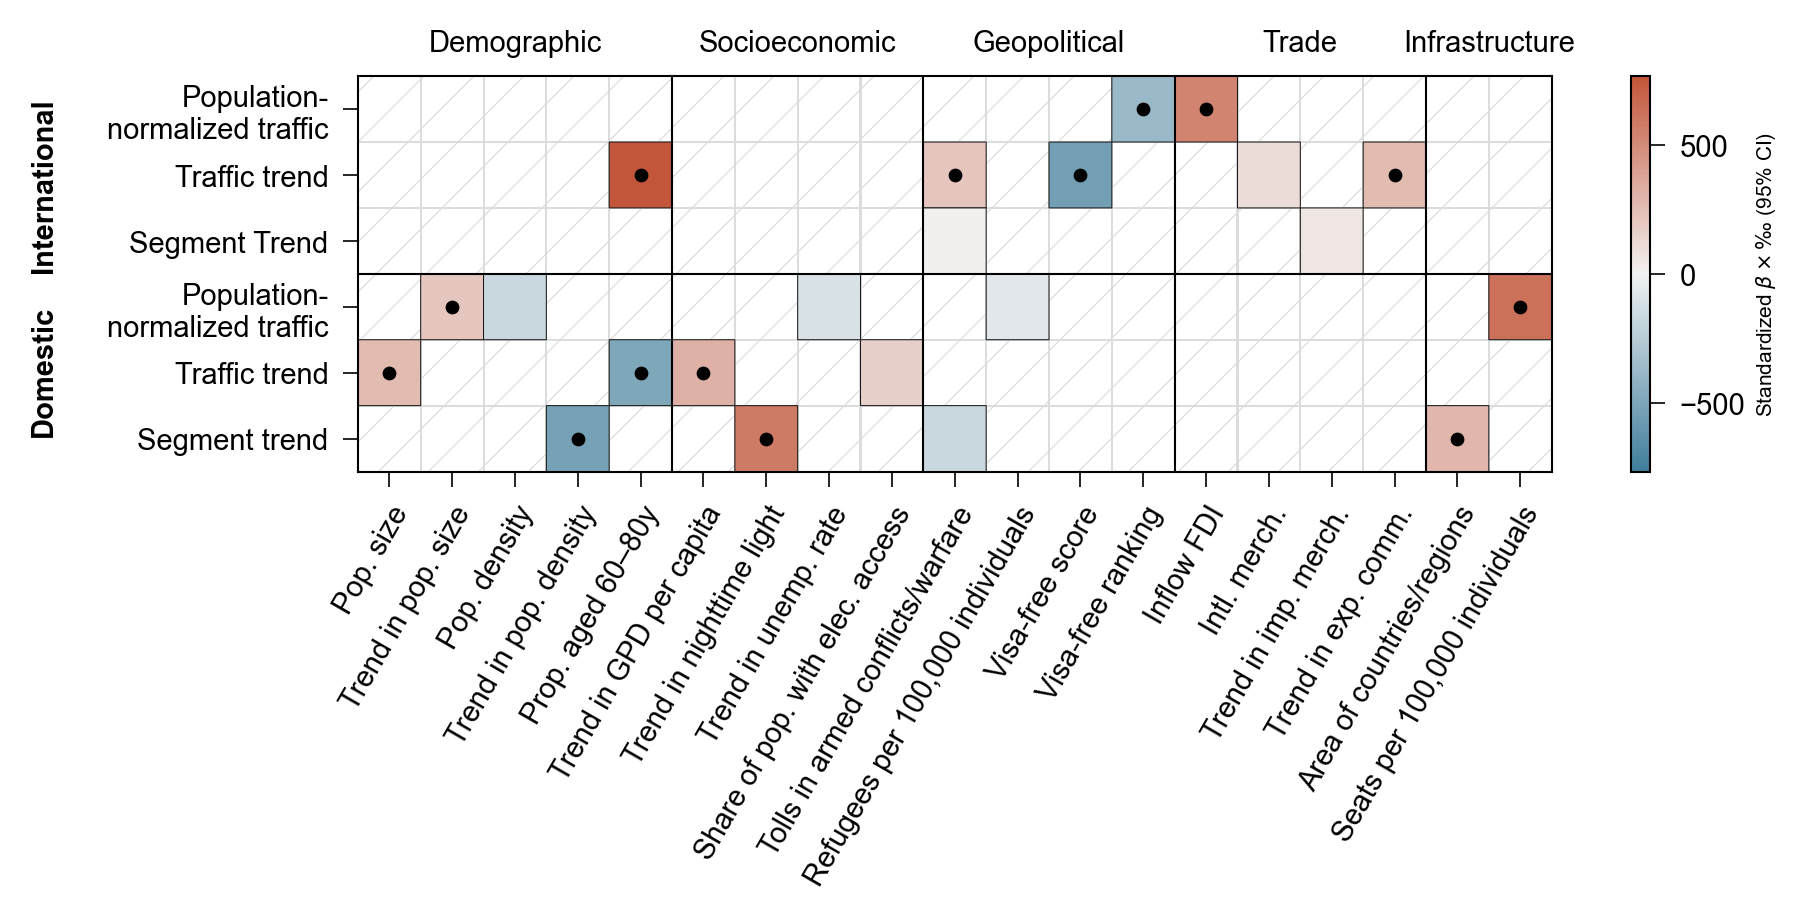

In [22]:
cm = 1 / 2.54  # centimeters in inches


style = {
    "lines.linewidth": 0.5,
    "lines.markeredgewidth": 0.3,
    "font.size": 5.0,
    "font.family": "Arial",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "axes.grid": False,
    "axes.labelsize": 5,
    "axes.labelpad": 2,
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "axes.xmargin": 0.01,
    "xtick.major.width": 0.4,
    "ytick.major.width": 0.4,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.titlepad": 0,
}


yticklabels = [
    'Pop. size', 
    'Trend in pop. size', 
    'Pop. density',
    'Trend in pop. density', 
    'Prop. aged 60–80y',
    'Trend in GPD per capita',
    'Trend in nighttime light', 
    'Trend in unemp. rate',
    'Share of pop. with elec. access',
    'Tolls in armed conflicts/warfare', 
    'Refugees per 100,000 individuals',
    'Visa-free score',
    'Visa-free ranking', 
    'Inflow FDI',
    'Intl. merch.',
    'Trend in imp. merch.', 
    'Trend in exp. comm.',
    'Area of countries/regions',
    'Seats per 100,000 individuals'
]


with mpl.rc_context(style):
    fig = plt.figure(figsize=(15 * cm, 7.5 * cm), dpi=300, layout="constrained")
    ax = plt.subplot()

    ax.pcolor(
        reg_.map(parse_res).T.map(pd.isna).values,
        cmap=ListedColormap(["white", "white"]),
        hatch="//",
        hatch_linewidth=0.3,
        color="#DCDCDC",
    )
    c = ax.pcolor(
        reg_.map(parse_res).T,
        cmap=sns.diverging_palette(230, 20, as_cmap=True),
        norm=mcolors.CenteredNorm(vcenter=0),
        edgecolor=".1",
    )

    fig.colorbar(c, ax=ax, label=r"Standardized $\beta \times \perthousand$ (95% CI)")

    a, b = reg_.shape
    X, Y = np.meshgrid(np.arange(a), np.arange(b))

    for a, b in zip(X, Y):
        for a_, b_ in zip(a, b):
            x = reg_.iloc[a_, b_]
            if isinstance(x, float):
                continue

            s, e = x.split(" ", 1)[1].split(", ")
            if float(s[1:].replace(",", "")) < 0 and float(e[:-1].replace(",", "")) > 0:
                pass
            else:
                ax.plot(a_ + 0.5, b_ + 0.5, "o", color="k", ms=3)

    ax.axvline(x=5, color="k")
    ax.axvline(x=9, color="k")
    ax.axvline(x=13, color="k")
    ax.axvline(x=17, color="k")

    ax.axhline(y=3, color="k")
    # plt.axhline(y=12, color='k')
    ax.set_xticks(
        np.arange(reg_.shape[0]) + 0.5,
        yticklabels,
        rotation=60,
        va="top",
        ha="right",
        rotation_mode="anchor",
    )
    ax.set_yticks(
        np.arange(reg_.shape[1]) + 0.5,
        ["Population-\nnormalized traffic", "Traffic trend", "Segment Trend", "Population-\nnormalized traffic", "Traffic trend", "Segment trend"],
    )
    ax.invert_yaxis()

    ax.text(
        0.01,
        0.81,
        "International",
        fontsize=7,
        fontweight="bold",
        rotation=90,
        va="center",
        ha="center",
        transform=fig.transFigure,
    )
    ax.text(
        0.01,
        0.6,
        "Domestic",
        fontsize=7,
        fontweight="bold",
        rotation=90,
        va="center",
        ha="center",
        transform=fig.transFigure,
    )

    ax.text(2.5, -0.5, "Demographic", fontsize=7, va="center", ha="center")
    ax.text(7, -0.5, "Socioeconomic", fontsize=7, va="center", ha="center")
    ax.text(11, -0.5, "Geopolitical", fontsize=7, va="center", ha="center")
    ax.text(15, -0.5, "Trade", fontsize=7, va="center", ha="center")
    ax.text(18, -0.5, "Infrastructure", fontsize=7, va="center", ha="center")

    fig.get_layout_engine().set(w_pad=4 / 72)
    plt.savefig("./Fig5.pdf")
    plt.show()